In [2]:
print('k')

k


In [2]:
import tensorflow as tf
print(tf.__version__)
import os

2.10.0


In [4]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# =========================
# CONFIG
# =========================
DATASET_DIR = "Data"
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
VAL_SPLIT = 0.2
NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"

torch.manual_seed(SEED)

# =========================
# TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(contrast=0.1),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# =========================
# LOAD TWO COPIES OF DATASET
# same files, different transforms
# =========================
full_dataset_train = datasets.ImageFolder(root=DATASET_DIR, transform=train_transform)
full_dataset_val = datasets.ImageFolder(root=DATASET_DIR, transform=val_transform)

# =========================
# SPLIT INDICES
# =========================
total_size = len(full_dataset_train)
val_size = int(total_size * VAL_SPLIT)
train_size = total_size - val_size

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(total_size, generator=generator).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(full_dataset_train, train_indices)
val_dataset = Subset(full_dataset_val, val_indices)

# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# =========================
# INFO
# =========================
class_names = full_dataset_train.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Device:", device)
print("Num workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)

Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
Number of classes: 6
Train size: 708
Val size: 177
Device: cuda
Num workers: 4
Pin memory: True


In [10]:
class_counts = {}
total_images = 0

for class_name in class_names:
  class_path = os.path.join(DATASET_DIR, class_name)
  count = len(os.listdir(class_path))
  class_counts[class_name] = count
  total_images += count

In [13]:
import torch

weights_list = []

for index, class_name in enumerate(class_names):
    weight = total_images / (NUM_CLASSES * class_counts[class_name])
    weights_list.append(weight)

# Convert to tensor
class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.7530, 0.7491, 0.7649, 1.4110, 2.1063, 1.1816], device='cuda:0')


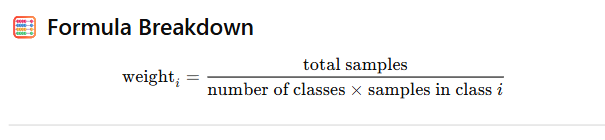

In [14]:
import os
import copy
from collections import Counter

import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

# Assumes train_loader, val_loader, NUM_CLASSES, class_weights, device are defined

# =========================
# CONFIG
# =========================
EPOCHS_HEAD = 20
EPOCHS_FINE = 5
PATIENCE = 3
SAVE_DIR = "saved_models"

os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

# =========================
# MODEL
# =========================
def build_model(hidden_units, dropout):
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

    # Freeze base features
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, hidden_units),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(hidden_units, NUM_CLASSES)
    )

    return model.to(device)

# =========================
# TRAIN / EVAL
# =========================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

# =========================
# OBJECTIVE
# =========================
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.3, 0.7)
    hidden_units = trial.suggest_int("hidden_units", 64, 256, step=32)
    fine_tune_lr = trial.suggest_float("fine_tune_lr", 1e-6, 5e-5, log=True)

    model = build_model(hidden_units, dropout)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Phase 1: Train head only
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )

    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(EPOCHS_HEAD):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        # Optuna pruning
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    # Restore best head-only model
    model.load_state_dict(best_state)

    # Phase 2: Fine-tune last 20 layers
    for param in model.features[-20:].parameters():
        param.requires_grad = True

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=fine_tune_lr
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )

    fine_best_acc = best_val_acc
    patience_counter = 0

    for epoch in range(EPOCHS_FINE):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        trial.report(val_acc, EPOCHS_HEAD + epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_acc > fine_best_acc:
            fine_best_acc = val_acc
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    model.load_state_dict(best_state)

    # Save with metadata
    save_path = os.path.join(SAVE_DIR, f"best_trial_{trial.number}.pth")
    torch.save({
        "trial_number": trial.number,
        "model_state_dict": model.state_dict(),
        "best_val_acc": fine_best_acc,
        "best_val_loss": best_val_loss,
        "params": trial.params,
        "class_to_idx": train_loader.dataset.dataset.class_to_idx if hasattr(train_loader.dataset.dataset, 'class_to_idx') else None,
    }, save_path)

    return fine_best_acc

# =========================
# RUN STUDY
# =========================
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=3)
)
study.optimize(objective, n_trials=10)

print("\n🔥 BEST TRIAL:")
print("Value:", study.best_trial.value)
print("Params:", study.best_trial.params)

[I 2026-04-04 17:05:34,297] A new study created in memory with name: no-name-296a4390-4372-4be9-82ac-3c6995c05035


[I 2026-04-04 17:09:17,035] Trial 0 finished with value: 0.6666666666666666 and parameters: {'lr': 4.130813790348812e-05, 'dropout': 0.6178963775919785, 'hidden_units': 224, 'fine_tune_lr': 1.6571250667568856e-05}. Best is trial 0 with value: 0.6666666666666666.
[I 2026-04-04 17:12:06,694] Trial 1 finished with value: 0.8192090395480226 and parameters: {'lr': 0.0008667173589629346, 'dropout': 0.6243630017830223, 'hidden_units': 96, 'fine_tune_lr': 3.29589089301912e-05}. Best is trial 1 with value: 0.8192090395480226.
[I 2026-04-04 17:14:58,579] Trial 2 finished with value: 0.8022598870056498 and parameters: {'lr': 0.0008353585324703996, 'dropout': 0.32723210370488315, 'hidden_units': 96, 'fine_tune_lr': 3.759559169529699e-06}. Best is trial 1 with value: 0.8192090395480226.
[I 2026-04-04 17:15:50,770] Trial 3 pruned. 
[I 2026-04-04 17:16:57,971] Trial 4 pruned. 
[I 2026-04-04 17:17:51,788] Trial 5 pruned. 
[I 2026-04-04 17:18:45,012] Trial 6 pruned. 
[I 2026-04-04 17:19:38,804] Trial 7


🔥 BEST TRIAL:
Value: 0.8192090395480226
Params: {'lr': 0.0008667173589629346, 'dropout': 0.6243630017830223, 'hidden_units': 96, 'fine_tune_lr': 3.29589089301912e-05}


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import copy

# =========================
# ⚙️ BEST PARAMS (FROM OPTUNA)
# =========================
LR = 0.0008667
DROPOUT = 0.624
HIDDEN_UNITS = 96
FINE_TUNE_LR = 3.29e-05

EPOCHS_HEAD = 30
EPOCHS_FINE = 10
PATIENCE = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 🧠 MODEL
# =========================
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Linear(in_features, HIDDEN_UNITS),
    nn.ReLU(),
    nn.Dropout(DROPOUT),
    nn.Linear(HIDDEN_UNITS, NUM_CLASSES)
)

model = model.to(device)

# =========================
# LOSS + OPTIMIZER
# =========================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR)

# =========================
# TRAIN FUNCTION
# =========================
def train_one_epoch(model, loader):
    model.train()
    correct, total = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

# =========================
# VALIDATION FUNCTION
# =========================
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

# =========================
# 🔥 PHASE 1: TRAIN HEAD
# =========================
best_acc = 0
patience_counter = 0
best_state = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS_HEAD):

    train_acc = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0

        torch.save(model.state_dict(), "best_model.pth")

    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("⛔ Early stopping")
        break

# =========================
# 🔥 PHASE 2: FINE-TUNE
# =========================
model.load_state_dict(best_state)

# Unfreeze last layers
for param in model.features[-40:].parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=FINE_TUNE_LR)

print("\n🔥 Starting Fine-Tuning...\n")

for epoch in range(EPOCHS_FINE):

    train_acc = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"[FT] Epoch {epoch+1} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

print("\n🏆 Final Best Accuracy:", best_acc)

Epoch 1 | Train: 0.4237 | Val: 0.5819
Epoch 2 | Train: 0.6497 | Val: 0.6836
Epoch 3 | Train: 0.7655 | Val: 0.7006
Epoch 4 | Train: 0.7585 | Val: 0.7062
Epoch 5 | Train: 0.7839 | Val: 0.7458
Epoch 6 | Train: 0.8277 | Val: 0.7345
Epoch 7 | Train: 0.8178 | Val: 0.7627
Epoch 8 | Train: 0.8164 | Val: 0.7514
Epoch 9 | Train: 0.8630 | Val: 0.7853
Epoch 10 | Train: 0.8305 | Val: 0.7627
Epoch 11 | Train: 0.8545 | Val: 0.7740
Epoch 12 | Train: 0.8404 | Val: 0.7853
Epoch 13 | Train: 0.8644 | Val: 0.8136
Epoch 14 | Train: 0.8644 | Val: 0.7966
Epoch 15 | Train: 0.8545 | Val: 0.8136
Epoch 16 | Train: 0.8856 | Val: 0.7853
Epoch 17 | Train: 0.8658 | Val: 0.7966
Epoch 18 | Train: 0.8686 | Val: 0.8192
Epoch 19 | Train: 0.8658 | Val: 0.7966
Epoch 20 | Train: 0.8997 | Val: 0.7797
Epoch 21 | Train: 0.8715 | Val: 0.7910
Epoch 22 | Train: 0.8686 | Val: 0.8023
Epoch 23 | Train: 0.8559 | Val: 0.8079
⛔ Early stopping

🔥 Starting Fine-Tuning...

[FT] Epoch 1 | Train: 0.8870 | Val: 0.8136
[FT] Epoch 2 | Train: 0.

I’ve worked primarily with TensorFlow/Keras, but I have implemented transfer learning and hyperparameter tuning workflows in PyTorch as well.

In [1]:
print(2)

2


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [2]:
import streamlit as st 
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
import numpy as np


In [3]:
# =========================
# ⚙️ SAME PARAMS
# =========================
DROPOUT = 0.624
HIDDEN_UNITS = 96
NUM_CLASSES = 6  # ⚠️ same as training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 🧠 LOAD MODEL
# =========================
def load_model():
    model = models.efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, HIDDEN_UNITS),
        nn.ReLU(),
        nn.Dropout(DROPOUT),
        nn.Linear(HIDDEN_UNITS, NUM_CLASSES)
    )

    model.load_state_dict(torch.load("best_model.pth", map_location=device))
    model.to(device)
    model.eval()

    return model

model = load_model()


In [ ]:
model.classifier


Sequential(
  (0): BatchNorm1d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (1): Linear(in_features=1280, out_features=96, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.624, inplace=False)
  (4): Linear(in_features=96, out_features=6, bias=True)
)

In [8]:
model.classifier[1].in_features


1280

In [ ]:
print(3)